# 01. EDA train.csv

Ноутбук посвящен только исследованию `train.csv`: качеству данных, структуре временного ряда, сезонности, лагам, выбросам, праздникам, зарплатным дням и другим сигналам для будущего обучения модели. В этом notebook модель не обучается, baseline не считается и forecast-файлы не создаются.


In [1]:
from __future__ import annotations

import warnings
from pathlib import Path

import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import Markdown, display

warnings.filterwarnings("ignore")

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams.update(
    {
        "figure.figsize": (12, 5),
        "figure.dpi": 110,
        "savefig.dpi": 160,
        "axes.titlesize": 15,
        "axes.labelsize": 11,
        "axes.titleweight": "bold",
        "legend.frameon": True,
        "legend.framealpha": 0.92,
        "font.size": 10,
        "font.family": "DejaVu Sans",
        "axes.unicode_minus": False,
    }
)

ROOT = Path.cwd()
if not (ROOT / "data").exists():
    ROOT = ROOT.parent

DATA_PATH = ROOT / "data" / "raw" / "train.csv"
FIG_DIR = ROOT / "artifacts" / "figures"
REPORT_DIR = ROOT / "artifacts" / "reports"
for path in (FIG_DIR, REPORT_DIR):
    path.mkdir(parents=True, exist_ok=True)

RANDOM_STATE = 42
DOW_ORDER = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
DOW_RU = ["Пн", "Вт", "Ср", "Чт", "Пт", "Сб", "Вс"]


def savefig(name: str) -> None:
    path = FIG_DIR / name
    plt.tight_layout()
    plt.savefig(path, bbox_inches="tight")
    print(f"saved: {path.relative_to(ROOT)}")


def format_date_axis(ax, locator: str = "year") -> None:
    if locator == "month":
        ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
        ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
    else:
        ax.xaxis.set_major_locator(mdates.YearLocator())
        ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
    ax.tick_params(axis="x", rotation=0)


def note(text: str) -> None:
    display(Markdown(text.strip()))

## 2. Загрузка данных

Загружаем `train.csv`, приводим типы и сразу фиксируем базовые границы ряда: период, часы работы,
количество дат и статистику `guests_count`.

In [2]:
raw = pd.read_csv(DATA_PATH)

display(raw.head())
display(raw.tail())
print(f"shape: {raw.shape}")
display(raw.describe(include="all"))
raw.info()

df = raw.copy()
df["sale_date"] = pd.to_datetime(df["sale_date"], errors="coerce")
df["sale_hour"] = pd.to_numeric(df["sale_hour"], errors="coerce").astype("Int64")
df["guests_count"] = pd.to_numeric(df["guests_count"], errors="coerce")
df = df.sort_values(["sale_date", "sale_hour"]).reset_index(drop=True)

observed_hours = sorted(df["sale_hour"].dropna().astype(int).unique())
basic_stats = pd.DataFrame(
    {
        "metric": [
            "date_min",
            "date_max",
            "unique_dates",
            "hour_min",
            "hour_max",
            "rows",
            "guests_mean",
            "guests_median",
            "guests_min",
            "guests_max",
        ],
        "value": [
            df["sale_date"].min().date(),
            df["sale_date"].max().date(),
            df["sale_date"].nunique(),
            min(observed_hours),
            max(observed_hours),
            len(df),
            round(df["guests_count"].mean(), 2),
            round(df["guests_count"].median(), 2),
            round(df["guests_count"].min(), 2),
            round(df["guests_count"].max(), 2),
        ],
    }
)
display(basic_stats)

display(Markdown(
    f"""
    **Вывод по загрузке.** В данных {len(df):,} строк за период
    `{df['sale_date'].min().date()} - {df['sale_date'].max().date()}`.
    Фактические значения `sale_hour`: `{min(observed_hours)}..{max(observed_hours)}`.
    Это согласуется с рабочим днем `7:00-23:00`: `sale_hour=22` означает интервал
    `22:00-23:00`. Для ML-прогноза нужен старт часа `7..22`; отдельного таргета
    `sale_hour=23` в истории нет.
    """
))

,sale_date,sale_hour,guests_count
0,2019-01-02,7,5
1,2019-01-02,8,11
2,2019-01-02,9,14
3,2019-01-02,10,17
4,2019-01-02,11,28


,sale_date,sale_hour,guests_count
40538,2026-04-26,18,127
40539,2026-04-26,19,128
40540,2026-04-26,20,100
40541,2026-04-26,21,70
40542,2026-04-26,22,76


shape: (40543, 3)


,sale_date,sale_hour,guests_count
count,40543,40543.000000,40543.000000
unique,2543,NaN,NaN
top,2019-01-02,NaN,NaN
freq,16,NaN,NaN
mean,NaN,14.502947,103.789729
std,NaN,4.606218,45.204182
min,NaN,7.000000,1.000000
25%,NaN,11.000000,70.000000
50%,NaN,15.000000,101.000000
75%,NaN,18.000000,135.000000


<class 'pandas.DataFrame'>
RangeIndex: 40543 entries, 0 to 40542
Data columns (total 3 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   sale_date     40543 non-null  str  
 1   sale_hour     40543 non-null  int64
 2   guests_count  40543 non-null  int64
dtypes: int64(2), str(1)
memory usage: 950.4 KB


,metric,value
0,date_min,2019-01-02
1,date_max,2026-04-26
2,unique_dates,2543
3,hour_min,7
4,hour_max,22
5,rows,40543
6,guests_mean,103.79
7,guests_median,101.0
8,guests_min,1
9,guests_max,299



    **Вывод по загрузке.** В данных 40,543 строк за период
    `2019-01-02 - 2026-04-26`.
    Фактические значения `sale_hour`: `7..22`.
    Это согласуется с рабочим днем `7:00-23:00`: `sale_hour=22` означает интервал
    `22:00-23:00`. Для ML-прогноза нужен старт часа `7..22`; отдельного таргета
    `sale_hour=23` в истории нет.
    

## Простой дневной график

Вход: `train.csv`. По оси X показаны годы и месяцы, по оси Y - суммарное количество гостей за день. Красная линия отмечает дату `2022-09-22`, после которой ряд визуально возвращается к более стабильному режиму после провала и восстановления 2022 года.


saved: artifacts\figures\00_daily_guests_by_year_month.png


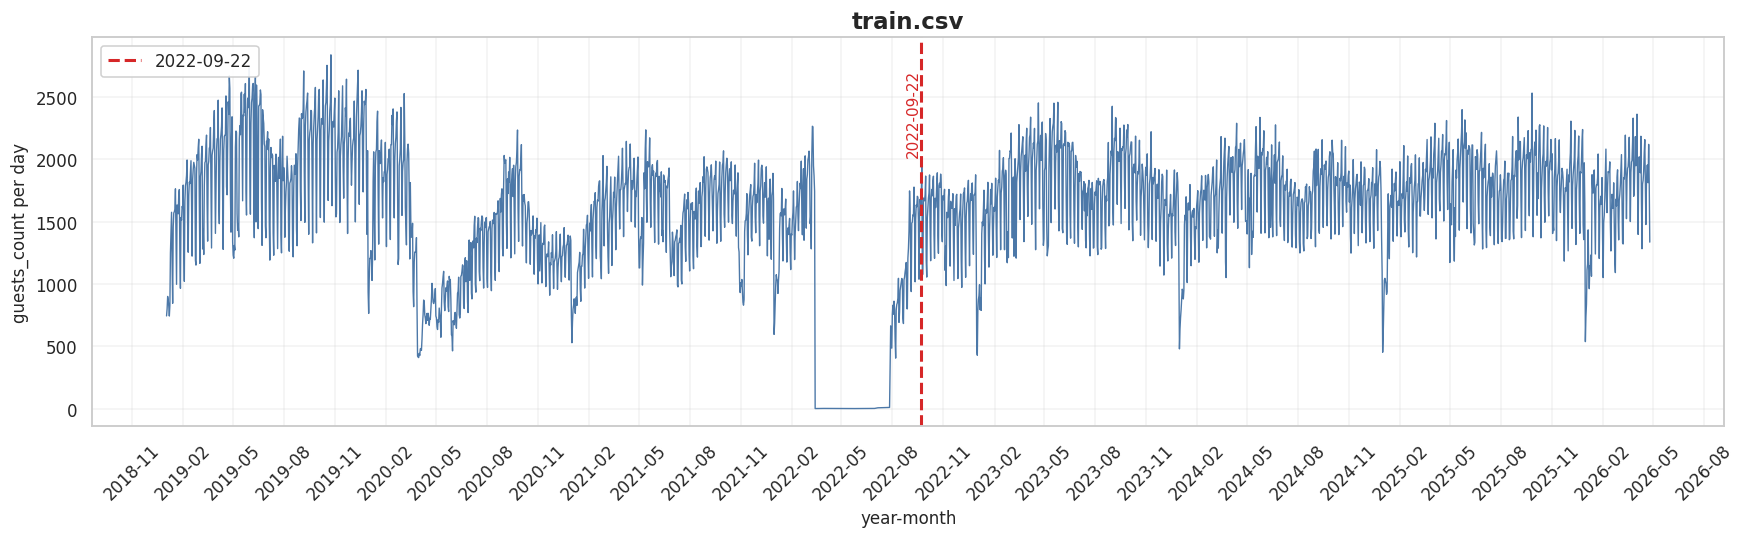

**Note.** The red vertical line marks `2022-09-22`: after the sharp growth, the series moves to a more stable level.

In [3]:
daily_guests_simple = (
    pd.read_csv(DATA_PATH, parse_dates=["sale_date"])
    .assign(guests_count=lambda x: pd.to_numeric(x["guests_count"], errors="coerce"))
    .groupby("sale_date", as_index=False)["guests_count"]
    .sum()
)

stabilization_date = pd.Timestamp("2022-09-22")

fig, ax = plt.subplots(figsize=(16, 5))
ax.plot(
    daily_guests_simple["sale_date"],
    daily_guests_simple["guests_count"],
    color="#4C78A8",
    linewidth=0.9,
)
ax.axvline(
    stabilization_date,
    color="#D62728",
    linestyle="--",
    linewidth=2,
    label="2022-09-22",
)
ax.text(
    stabilization_date,
    daily_guests_simple["guests_count"].max() * 0.96,
    "2022-09-22",
    color="#D62728",
    rotation=90,
    va="top",
    ha="right",
    fontsize=10,
)
ax.set_title("train.csv")
ax.set_xlabel("year-month")
ax.set_ylabel("guests_count per day")
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
ax.tick_params(axis="x", rotation=45)
ax.grid(True, alpha=0.25)
ax.legend(loc="upper left")
savefig("00_daily_guests_by_year_month.png")
plt.show()

note("""
**Note.** The red vertical line marks `2022-09-22`: after the sharp growth, the series moves to a more stable level.
""")

## 3. Проверка качества данных

Проверяем пропуски, дубли по ключу `sale_date + sale_hour`, отрицательные и нулевые значения,
часы вне рабочего окна, неполные дни, разрывы временной сетки и аномально большие значения.

,Проверка,Значение
0,Пропуски во всех колонках,0.0
1,Дубли sale_date + sale_hour,0.0
2,Отрицательный guests_count,0.0
3,Нулевой guests_count,0.0
4,Пропущенные слоты дата-час,2209.0
5,Неполные дни,30.0
6,IQR-выбросы по часам,231.0
7,Верхний IQR-порог guests_count,232.5


saved: artifacts\figures\01_missing_values.png


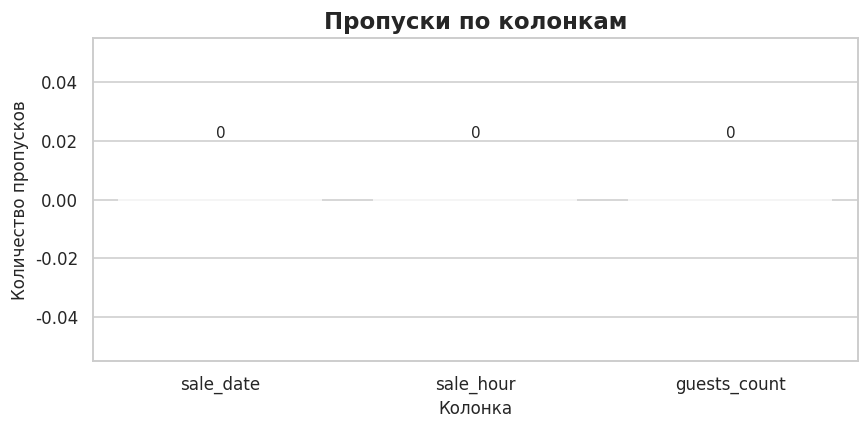

**Вывод.** Этот график быстро проверяет, можно ли обучать модель без дополнительной импутации.
Если пропуски появились бы в `sale_date`, `sale_hour` или `guests_count`, их нужно было бы обработать до любых лагов.

saved: artifacts\figures\02_hours_per_day.png


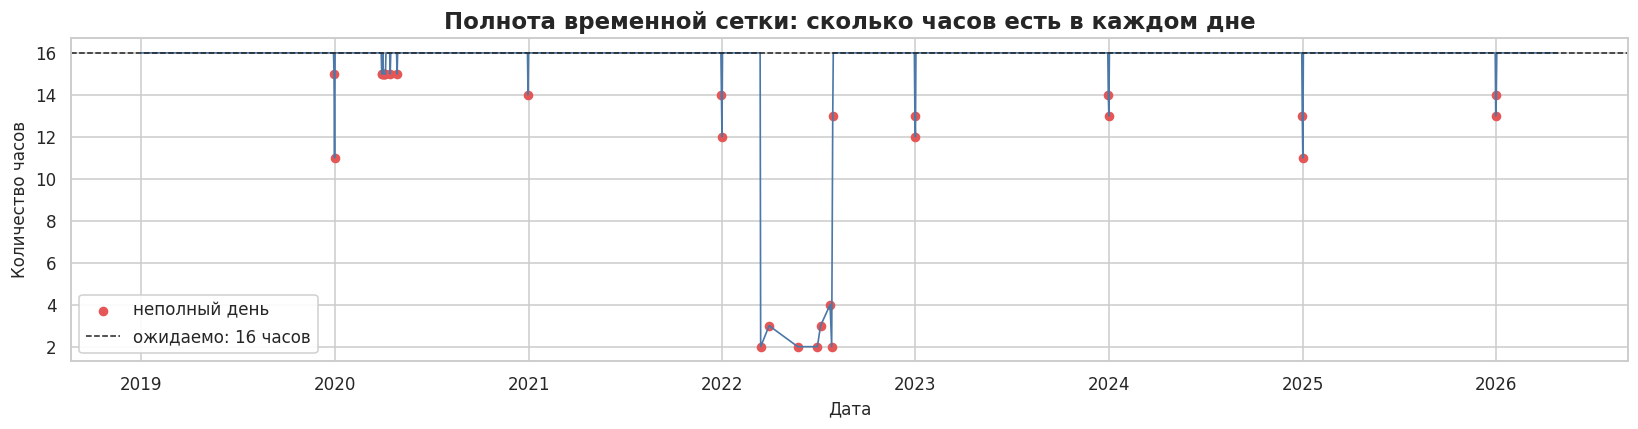

**Вывод.** В фактическом окне `7:00-23:00` неполных дней: `30`.
Неполные дни важны для ML, потому что rolling- и lag-признаки могут получить искусственные провалы.

saved: artifacts\figures\03_guests_distribution_and_boxplot.png


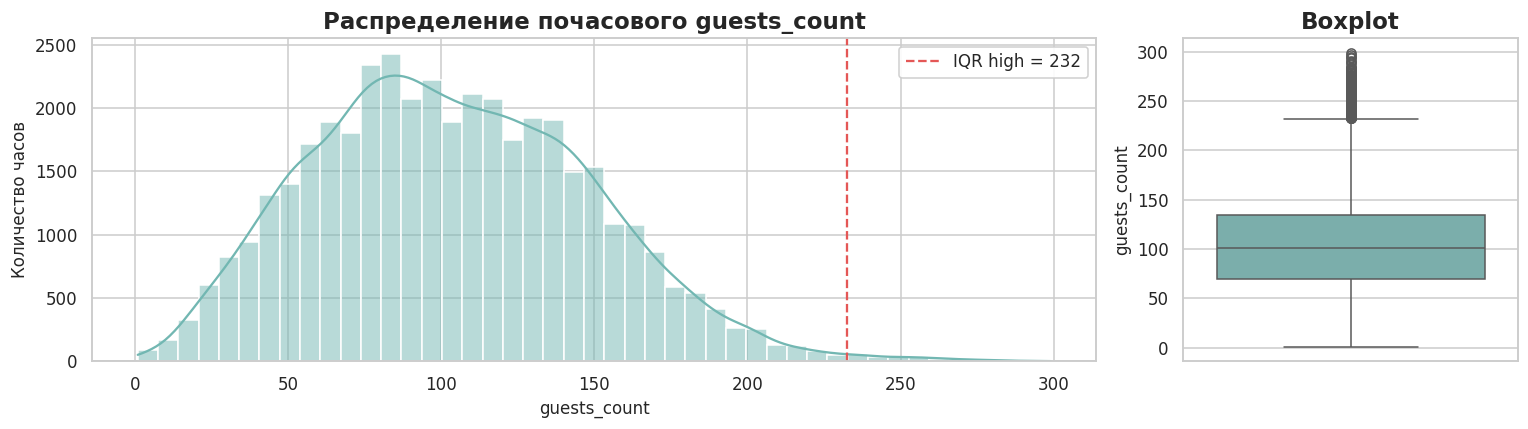

**Вывод.** Распределение асимметрично: пики спроса выше типичного уровня встречаются, но максимум `299`
похож на бизнес-пик, а не на очевидную ошибку. Такие точки лучше не удалять автоматически: модель должна понимать пиковые часы.

,sale_date,hours_count
363,2019-12-31,15
364,2020-01-01,11
453,2020-03-30,15
454,2020-03-31,15
456,2020-04-02,15
457,2020-04-03,15
458,2020-04-04,15
459,2020-04-05,15
460,2020-04-06,15
469,2020-04-15,15


In [4]:
min_hour, max_hour = min(observed_hours), max(observed_hours)
expected_hours = list(range(min_hour, max_hour + 1))
full_grid = pd.MultiIndex.from_product(
    [pd.date_range(df["sale_date"].min(), df["sale_date"].max(), freq="D"), expected_hours],
    names=["sale_date", "sale_hour"],
).to_frame(index=False)
grid_check = full_grid.merge(df, on=["sale_date", "sale_hour"], how="left", indicator=True)
missing_grid = grid_check[grid_check["_merge"] == "left_only"]

hours_per_day = df.groupby("sale_date")["sale_hour"].nunique().rename("hours_count").reset_index()
incomplete_days = hours_per_day[hours_per_day["hours_count"] < len(expected_hours)]

q1, q3 = df["guests_count"].quantile([0.25, 0.75])
iqr = q3 - q1
high_threshold = q3 + 1.5 * iqr
low_threshold = max(0, q1 - 1.5 * iqr)
outlier_rows = df[(df["guests_count"] > high_threshold) | (df["guests_count"] < low_threshold)]

quality_report = pd.DataFrame(
    {
        "Проверка": [
            "Пропуски во всех колонках",
            "Дубли sale_date + sale_hour",
            "Отрицательный guests_count",
            "Нулевой guests_count",
            "Пропущенные слоты дата-час",
            "Неполные дни",
            "IQR-выбросы по часам",
            "Верхний IQR-порог guests_count",
        ],
        "Значение": [
            int(df.isna().sum().sum()),
            int(df.duplicated(["sale_date", "sale_hour"]).sum()),
            int((df["guests_count"] < 0).sum()),
            int((df["guests_count"] == 0).sum()),
            int(len(missing_grid)),
            int(len(incomplete_days)),
            int(len(outlier_rows)),
            round(float(high_threshold), 2),
        ],
    }
)
display(quality_report)

fig, ax = plt.subplots(figsize=(8, 4))
missing = df.isna().sum().sort_values(ascending=False)
bars = sns.barplot(x=missing.index, y=missing.values, ax=ax, color="#4C78A8")
ax.set_title("Пропуски по колонкам")
ax.set_xlabel("Колонка")
ax.set_ylabel("Количество пропусков")
for bar, value in zip(bars.patches, missing.values):
    ax.text(bar.get_x() + bar.get_width() / 2, value + 0.02, str(int(value)), ha="center", va="bottom")
savefig("01_missing_values.png")
plt.show()
note("""
**Вывод.** Этот график быстро проверяет, можно ли обучать модель без дополнительной импутации.
Если пропуски появились бы в `sale_date`, `sale_hour` или `guests_count`, их нужно было бы обработать до любых лагов.
""")

fig, ax = plt.subplots(figsize=(15, 4))
ax.plot(hours_per_day["sale_date"], hours_per_day["hours_count"], linewidth=1.1, color="#4C78A8")
if not incomplete_days.empty:
    ax.scatter(incomplete_days["sale_date"], incomplete_days["hours_count"], color="#E45756", s=28, label="неполный день")
ax.axhline(len(expected_hours), color="#222222", linestyle="--", linewidth=1, label=f"ожидаемо: {len(expected_hours)} часов")
ax.set_title("Полнота временной сетки: сколько часов есть в каждом дне")
ax.set_xlabel("Дата")
ax.set_ylabel("Количество часов")
format_date_axis(ax)
ax.legend(loc="lower left")
savefig("02_hours_per_day.png")
plt.show()
note(f"""
**Вывод.** В фактическом окне `{min_hour}:00-{max_hour + 1}:00` неполных дней: `{len(incomplete_days)}`.
Неполные дни важны для ML, потому что rolling- и lag-признаки могут получить искусственные провалы.
""")

fig, axes = plt.subplots(1, 2, figsize=(14, 4), gridspec_kw={"width_ratios": [3, 1]})
sns.histplot(df["guests_count"], bins=45, kde=True, ax=axes[0], color="#72B7B2")
axes[0].axvline(high_threshold, color="#E45756", linestyle="--", label=f"IQR high = {high_threshold:.0f}")
axes[0].set_title("Распределение почасового guests_count")
axes[0].set_xlabel("guests_count")
axes[0].set_ylabel("Количество часов")
axes[0].legend()
sns.boxplot(data=df, y="guests_count", ax=axes[1], color="#72B7B2")
axes[1].set_title("Boxplot")
axes[1].set_ylabel("guests_count")
savefig("03_guests_distribution_and_boxplot.png")
plt.show()
note(f"""
**Вывод.** Распределение асимметрично: пики спроса выше типичного уровня встречаются, но максимум `{df['guests_count'].max():.0f}`
похож на бизнес-пик, а не на очевидную ошибку. Такие точки лучше не удалять автоматически: модель должна понимать пиковые часы.
""")

if not incomplete_days.empty:
    display(incomplete_days.head(15))
else:
    note("**Вывод.** Неполных дней относительно фактического окна часов не найдено.")

## 4. Базовая структура временного ряда

Создаем `timestamp = sale_date + sale_hour` и смотрим ряд во времени, сглаживания,
недельную и месячную агрегации.

saved: artifacts\figures\04_daily_trend_rolling.png


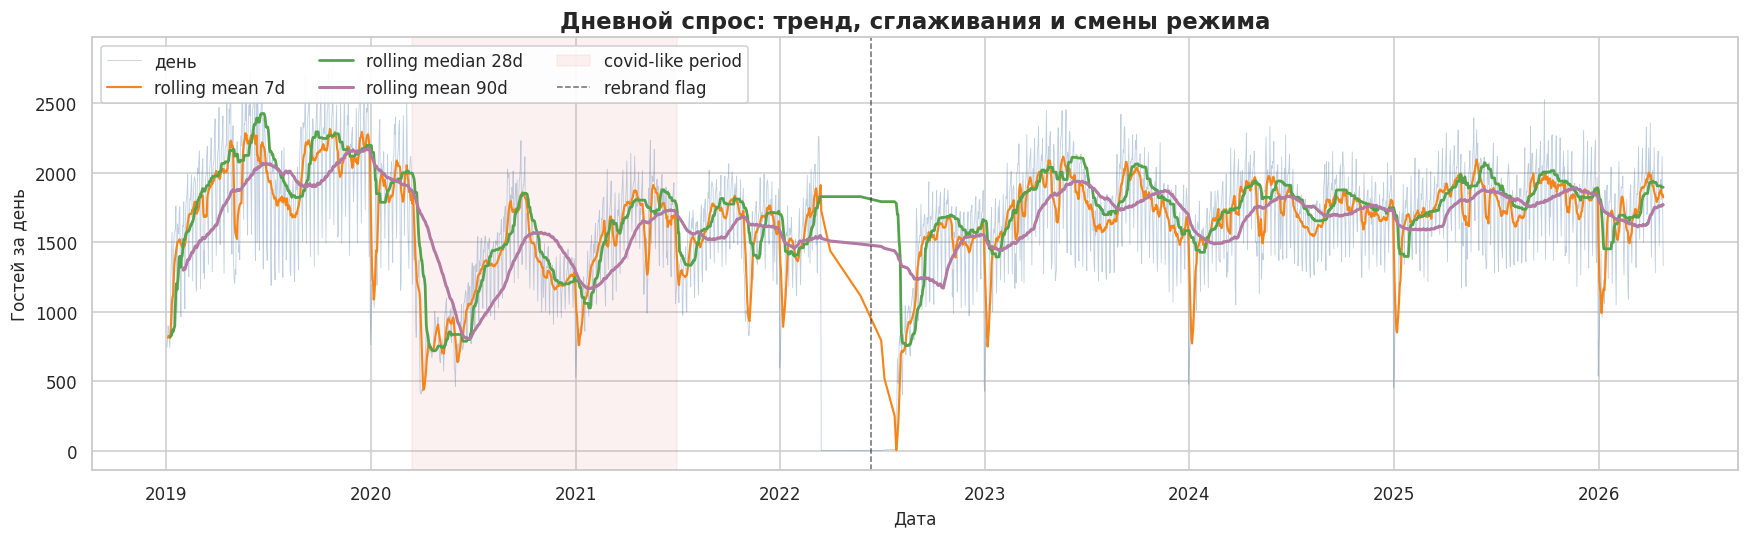

**Вывод.** Rolling-линии отделяют устойчивый уровень спроса от шумных дневных колебаний.
Для модели это аргумент в пользу `days_from_start`, флагов нестабильных периодов и rolling-признаков.

saved: artifacts\figures\05_weekly_monthly_trends.png


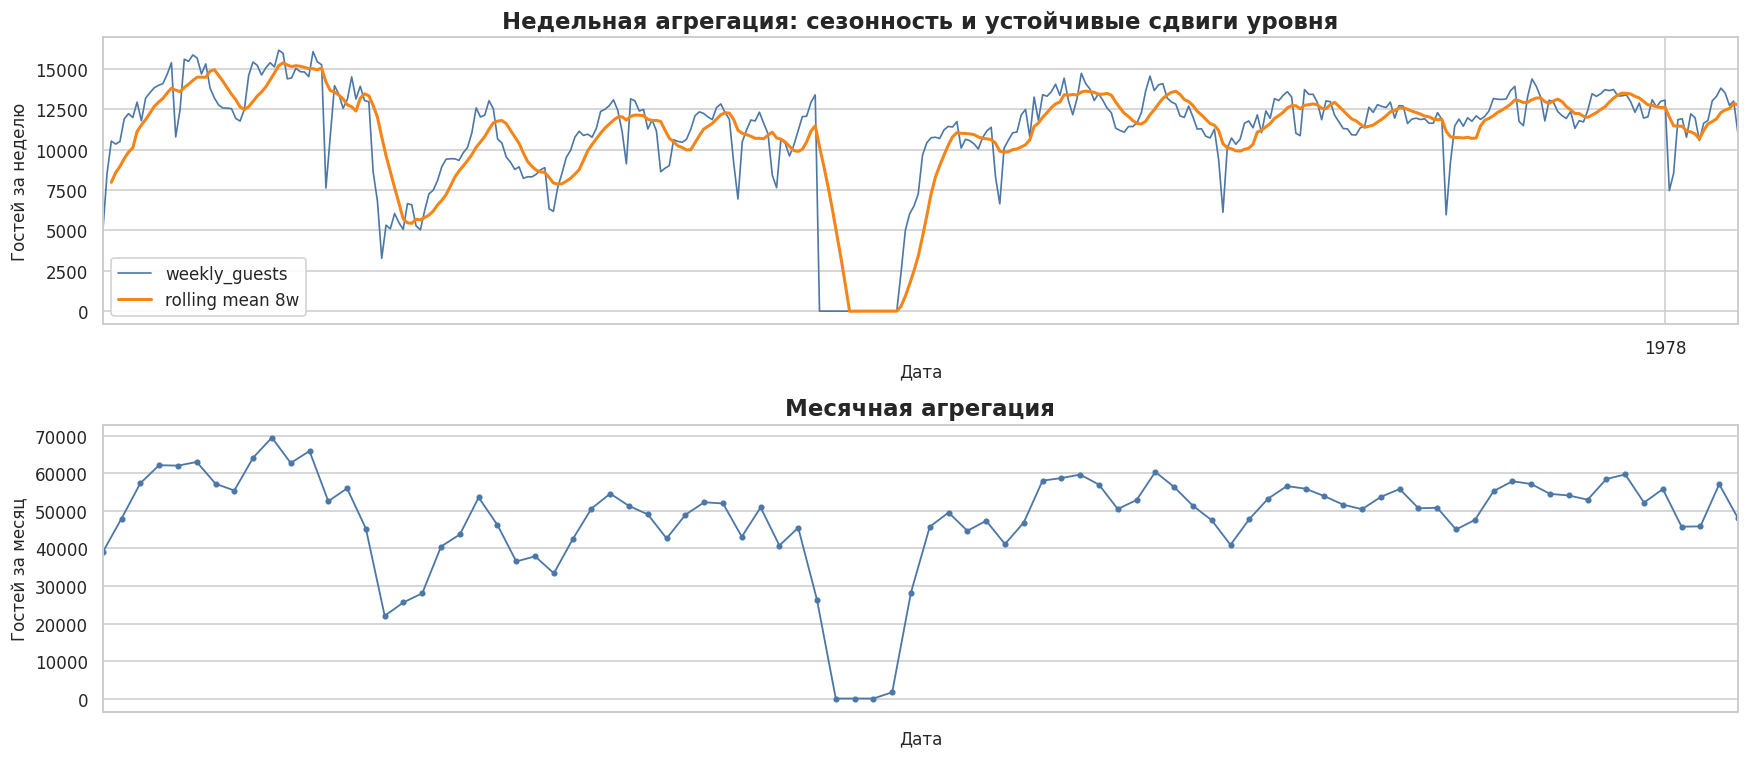

**Вывод.** Агрегации показывают, насколько меняется базовый уровень ряда по месяцам и годам.
Если уровень спроса плывет, модель только с `day_of_week + hour` будет систематически ошибаться на новых периодах.

In [5]:
df["timestamp"] = df["sale_date"] + pd.to_timedelta(df["sale_hour"].astype(int), unit="h")
df["date"] = df["sale_date"].dt.date
daily = df.groupby("sale_date", as_index=False).agg(
    guests_sum=("guests_count", "sum"),
    guests_mean=("guests_count", "mean"),
    hours=("sale_hour", "nunique"),
)
daily["rolling_7d_mean"] = daily["guests_sum"].rolling(7, min_periods=3).mean()
daily["rolling_28d_median"] = daily["guests_sum"].rolling(28, min_periods=7).median()
daily["rolling_90d_mean"] = daily["guests_sum"].rolling(90, min_periods=30).mean()
weekly = daily.set_index("sale_date")["guests_sum"].resample("W-MON").sum().rename("weekly_guests")
monthly = daily.set_index("sale_date")["guests_sum"].resample("MS").sum().rename("monthly_guests")

fig, ax = plt.subplots(figsize=(16, 5))
ax.plot(daily["sale_date"], daily["guests_sum"], linewidth=0.55, alpha=0.35, color="#4C78A8", label="день")
ax.plot(daily["sale_date"], daily["rolling_7d_mean"], linewidth=1.4, color="#F58518", label="rolling mean 7d")
ax.plot(daily["sale_date"], daily["rolling_28d_median"], linewidth=1.8, color="#54A24B", label="rolling median 28d")
ax.plot(daily["sale_date"], daily["rolling_90d_mean"], linewidth=2.0, color="#B279A2", label="rolling mean 90d")
ax.axvspan(pd.Timestamp("2020-03-15"), pd.Timestamp("2021-06-30"), color="#E45756", alpha=0.08, label="covid-like period")
ax.axvline(pd.Timestamp("2022-06-12"), color="#222222", linestyle="--", linewidth=1, alpha=0.65, label="rebrand flag")
ax.set_title("Дневной спрос: тренд, сглаживания и смены режима")
ax.set_xlabel("Дата")
ax.set_ylabel("Гостей за день")
format_date_axis(ax)
ax.legend(ncol=3, loc="upper left")
savefig("04_daily_trend_rolling.png")
plt.show()
note("""
**Вывод.** Rolling-линии отделяют устойчивый уровень спроса от шумных дневных колебаний.
Для модели это аргумент в пользу `days_from_start`, флагов нестабильных периодов и rolling-признаков.
""")

fig, axes = plt.subplots(2, 1, figsize=(16, 7), sharex=False)
weekly.plot(ax=axes[0], color="#4C78A8", linewidth=1.1)
weekly.rolling(8, min_periods=3).mean().plot(ax=axes[0], color="#F58518", linewidth=2, label="rolling mean 8w")
axes[0].set_title("Недельная агрегация: сезонность и устойчивые сдвиги уровня")
axes[0].set_xlabel("Дата")
axes[0].set_ylabel("Гостей за неделю")
format_date_axis(axes[0])
axes[0].legend()
monthly.plot(ax=axes[1], color="#4C78A8", marker="o", markersize=3, linewidth=1.2)
axes[1].set_title("Месячная агрегация")
axes[1].set_xlabel("Дата")
axes[1].set_ylabel("Гостей за месяц")
format_date_axis(axes[1])
savefig("05_weekly_monthly_trends.png")
plt.show()
note("""
**Вывод.** Агрегации показывают, насколько меняется базовый уровень ряда по месяцам и годам.
Если уровень спроса плывет, модель только с `day_of_week + hour` будет систематически ошибаться на новых периодах.
""")

## 5. Сезонность и зависимости

Проверяем зависимости от часа, дня недели, месяца, типа дня, утреннего меню и основного меню.

saved: artifacts\figures\06_hourly_seasonality.png


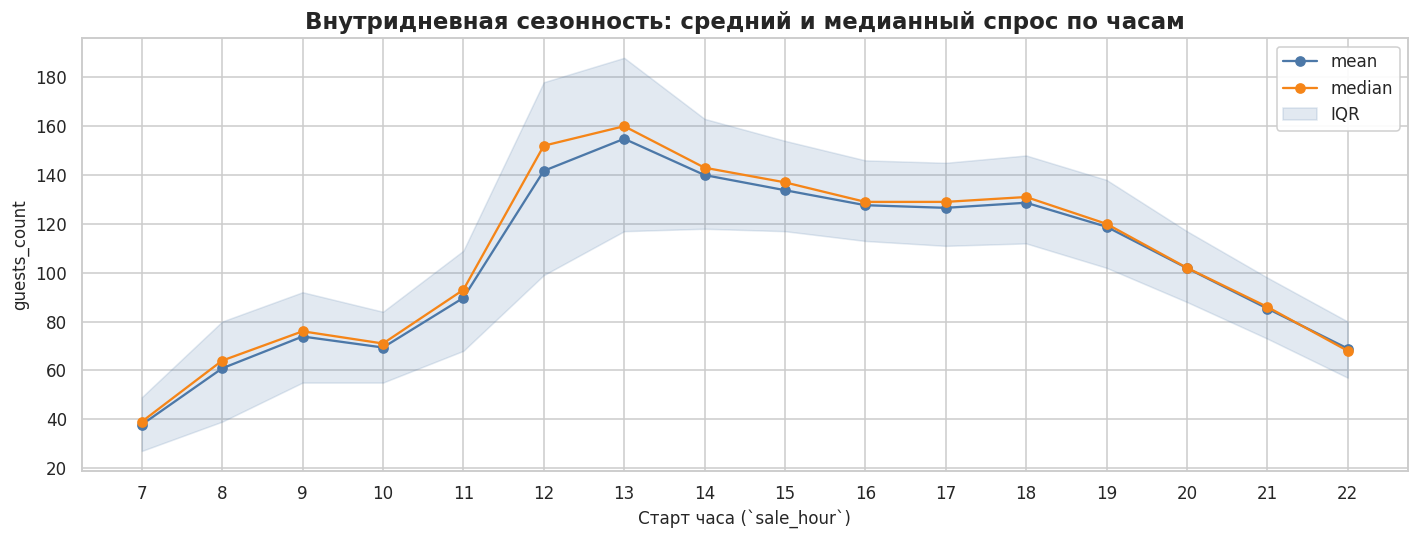

**Вывод.** Самый загруженный час по среднему значению: `13`.
Самый слабый час: `7`. Час дня - обязательный признак модели.

saved: artifacts\figures\07_hour_boxplot_and_weekday_bar.png


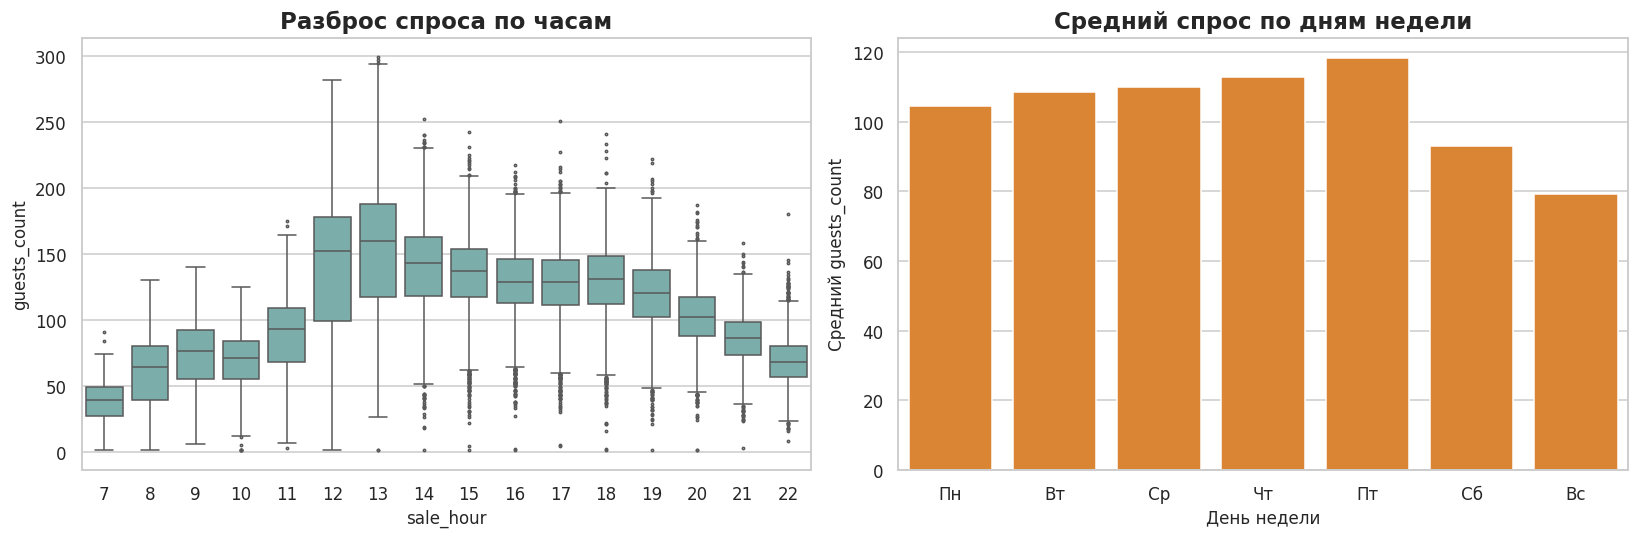

**Вывод.** Boxplot показывает, в какие часы ошибка прогноза потенциально дороже из-за большого разброса.
Дни недели заметно различаются, поэтому random split был бы некорректен и сгладил бы недельный паттерн.

saved: artifacts\figures\08_heatmap_dow_hour.png


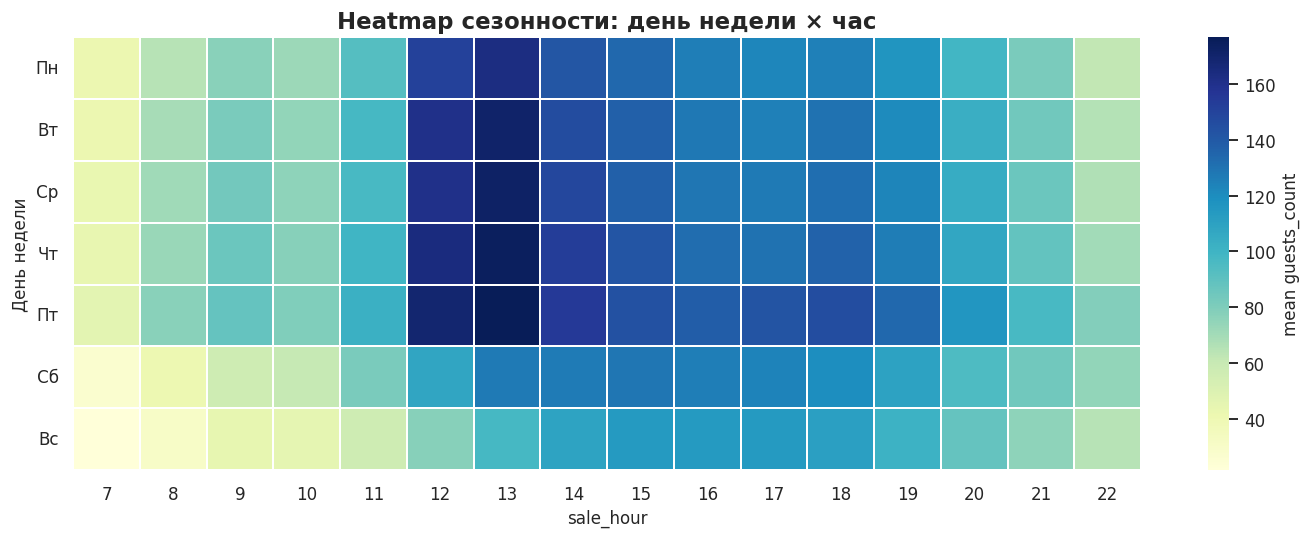

**Вывод.** Эта heatmap отвечает на главный вопрос сезонности: спрос зависит не только от часа и не только от дня,
а от их комбинации. Поэтому baseline `day_of_week + sale_hour` является сильной точкой отсчета.

saved: artifacts\figures\09_heatmap_recent_date_hour.png


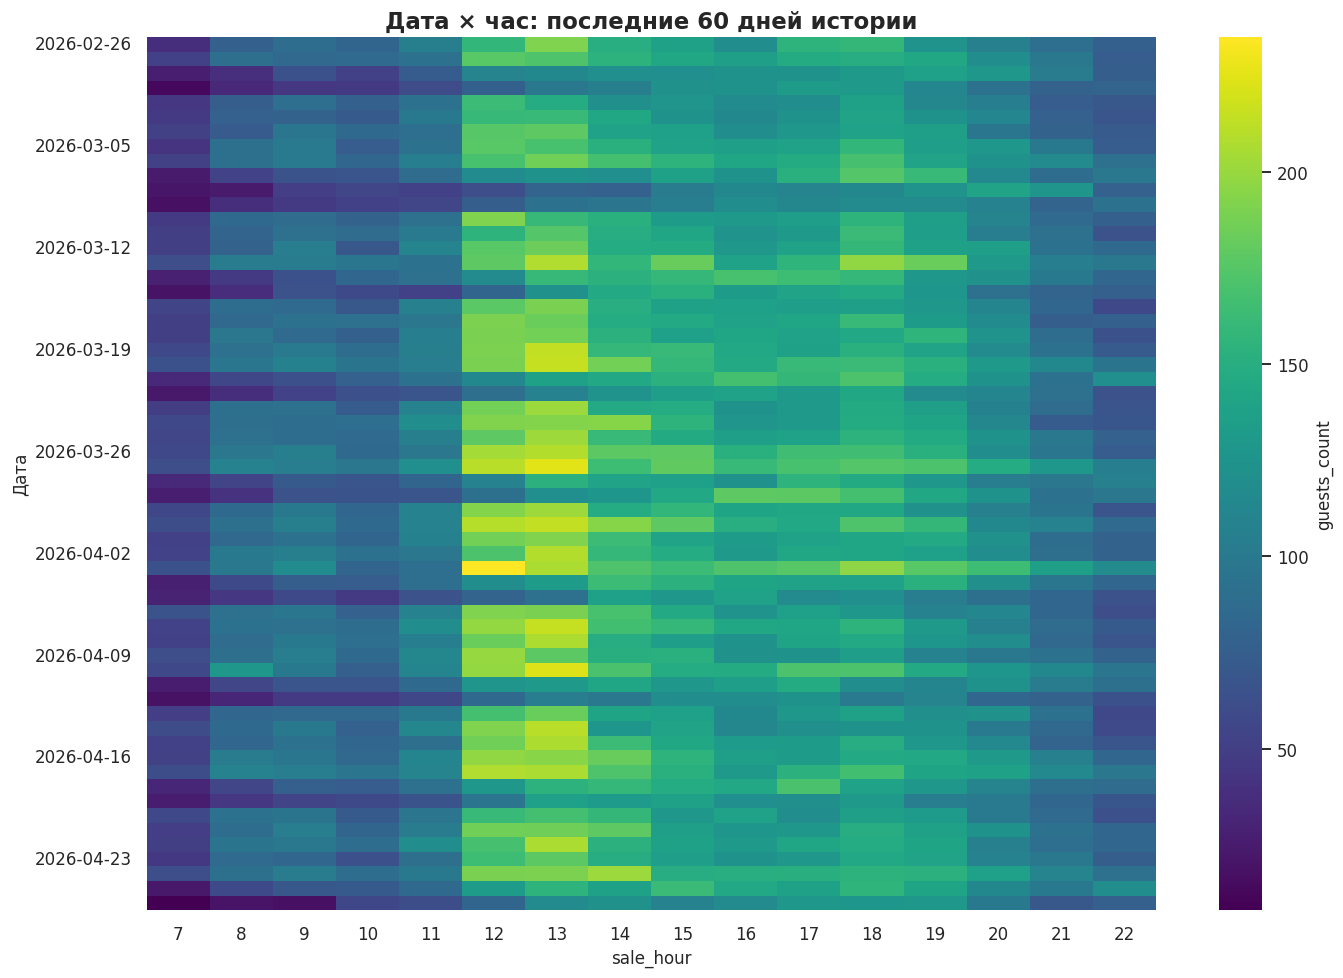

**Вывод.** Heatmap последних дней помогает увидеть локальные пики/провалы перед прогнозным периодом.
Это полезно для выбора recent-baseline и для диагностики, не меняется ли режим спроса прямо перед holdout.

saved: artifacts\figures\10_weekend_and_menu_effects.png


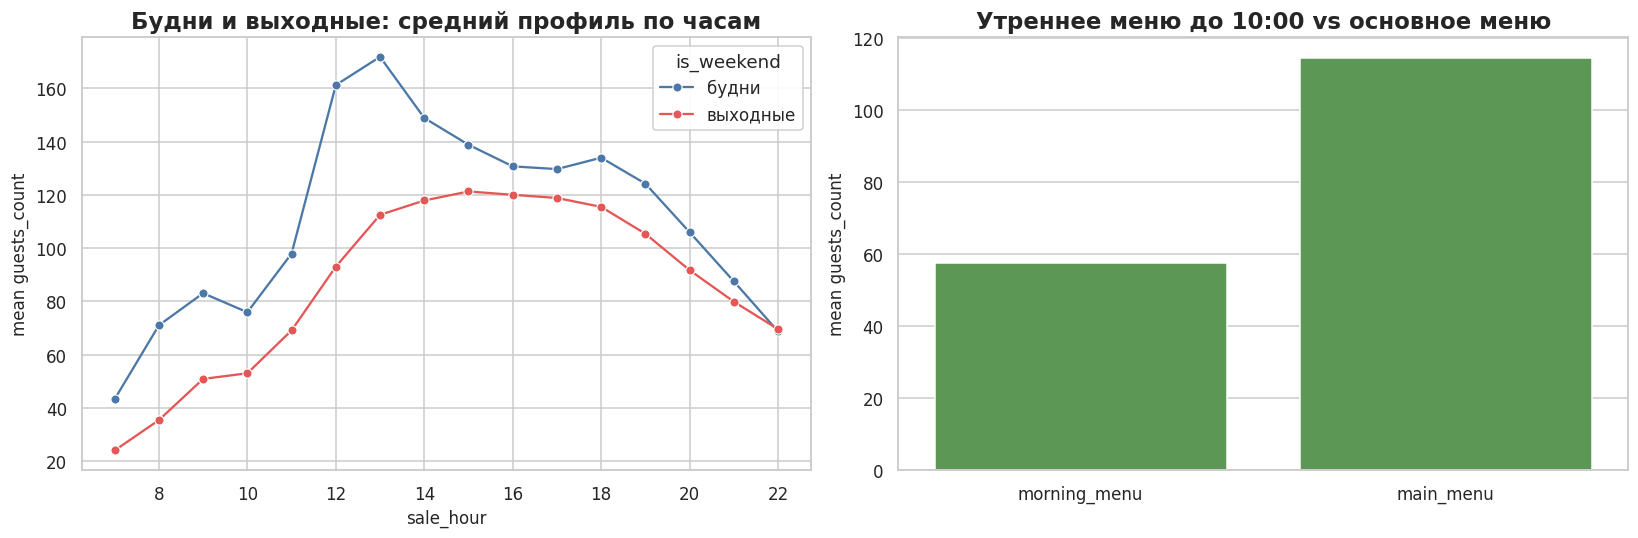

,mean,median,count
menu_period,,,
morning_menu,57.518670,54.0,7579
main_menu,114.428255,113.0,32964


**Вывод.** Различие утренних и основных часов подтверждает признак `is_morning_menu`.
Различие будней и выходных подтверждает `is_weekend` и отдельные паттерны по `day_of_week`.

saved: artifacts\figures\11_heatmap_year_month.png


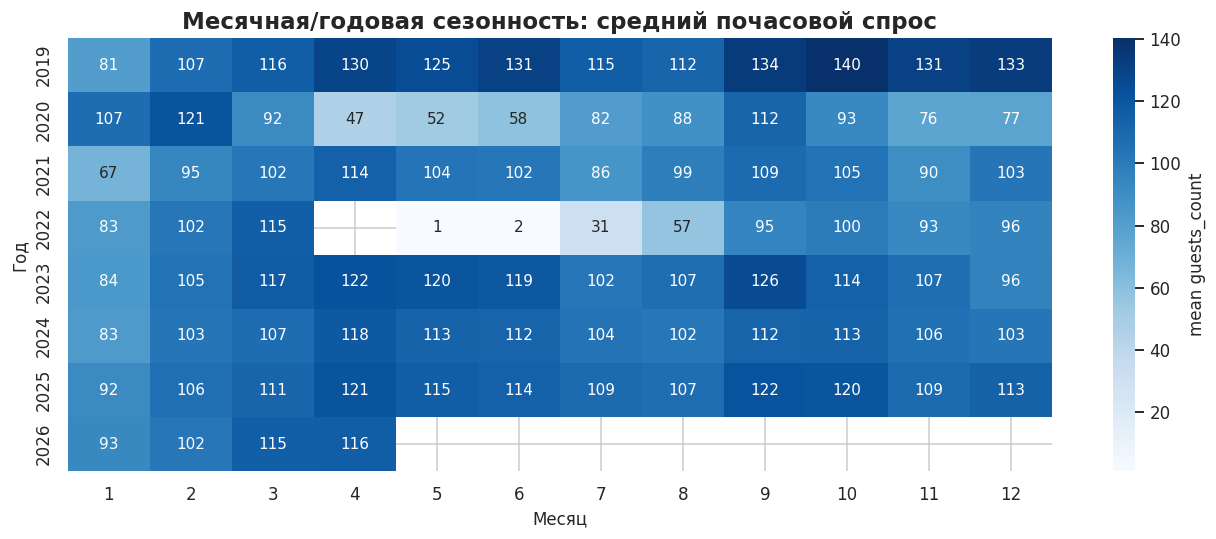

**Вывод.** Год-месяц heatmap показывает долгосрочные сдвиги уровня и месячную сезонность.
Для первой модели это обосновывает признаки `month`, `week_of_year`, `year`, `days_from_start`.

In [6]:
df["day_of_week"] = df["sale_date"].dt.dayofweek
df["weekday_name"] = df["sale_date"].dt.day_name()
df["month"] = df["sale_date"].dt.month
df["year"] = df["sale_date"].dt.year
df["is_weekend"] = df["day_of_week"].isin([5, 6])
df["menu_period"] = np.where(df["sale_hour"].astype(int) < 10, "morning_menu", "main_menu")

hour_stats = df.groupby("sale_hour")["guests_count"].agg(
    mean="mean", median="median", q25=lambda x: x.quantile(0.25), q75=lambda x: x.quantile(0.75)
).reset_index()
fig, ax = plt.subplots(figsize=(13, 5))
ax.plot(hour_stats["sale_hour"], hour_stats["mean"], marker="o", color="#4C78A8", label="mean")
ax.plot(hour_stats["sale_hour"], hour_stats["median"], marker="o", color="#F58518", label="median")
ax.fill_between(hour_stats["sale_hour"], hour_stats["q25"], hour_stats["q75"], color="#4C78A8", alpha=0.16, label="IQR")
ax.set_title("Внутридневная сезонность: средний и медианный спрос по часам")
ax.set_xlabel("Старт часа (`sale_hour`)")
ax.set_ylabel("guests_count")
ax.set_xticks(expected_hours)
ax.legend()
savefig("06_hourly_seasonality.png")
plt.show()
note(f"""
**Вывод.** Самый загруженный час по среднему значению: `{hour_stats.loc[hour_stats['mean'].idxmax(), 'sale_hour']}`.
Самый слабый час: `{hour_stats.loc[hour_stats['mean'].idxmin(), 'sale_hour']}`. Час дня - обязательный признак модели.
""")

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
sns.boxplot(data=df, x="sale_hour", y="guests_count", ax=axes[0], color="#72B7B2", fliersize=1.5)
axes[0].set_title("Разброс спроса по часам")
axes[0].set_xlabel("sale_hour")
axes[0].set_ylabel("guests_count")
weekday_mean = df.groupby("weekday_name")["guests_count"].mean().reindex(DOW_ORDER)
sns.barplot(x=DOW_RU, y=weekday_mean.values, ax=axes[1], color="#F58518")
axes[1].set_title("Средний спрос по дням недели")
axes[1].set_xlabel("День недели")
axes[1].set_ylabel("Средний guests_count")
savefig("07_hour_boxplot_and_weekday_bar.png")
plt.show()
note("""
**Вывод.** Boxplot показывает, в какие часы ошибка прогноза потенциально дороже из-за большого разброса.
Дни недели заметно различаются, поэтому random split был бы некорректен и сгладил бы недельный паттерн.
""")

pivot_dow_hour = df.pivot_table(index="weekday_name", columns="sale_hour", values="guests_count", aggfunc="mean").reindex(DOW_ORDER)
fig, ax = plt.subplots(figsize=(13, 5))
sns.heatmap(pivot_dow_hour, cmap="YlGnBu", linewidths=0.25, linecolor="white", ax=ax, cbar_kws={"label": "mean guests_count"})
ax.set_yticklabels(DOW_RU, rotation=0)
ax.set_title("Heatmap сезонности: день недели × час")
ax.set_xlabel("sale_hour")
ax.set_ylabel("День недели")
savefig("08_heatmap_dow_hour.png")
plt.show()
note("""
**Вывод.** Эта heatmap отвечает на главный вопрос сезонности: спрос зависит не только от часа и не только от дня,
а от их комбинации. Поэтому baseline `day_of_week + sale_hour` является сильной точкой отсчета.
""")

recent_for_heatmap = df[df["sale_date"] >= df["sale_date"].max() - pd.Timedelta(days=59)].copy()
pivot_date_hour = recent_for_heatmap.pivot_table(index="sale_date", columns="sale_hour", values="guests_count", aggfunc="mean")
fig, ax = plt.subplots(figsize=(13, 9))
sns.heatmap(pivot_date_hour, cmap="viridis", ax=ax, cbar_kws={"label": "guests_count"})
ax.set_title("Дата × час: последние 60 дней истории")
ax.set_xlabel("sale_hour")
ax.set_ylabel("Дата")
ax.set_yticks(np.arange(0, len(pivot_date_hour), 7) + 0.5)
ax.set_yticklabels([d.strftime("%Y-%m-%d") for d in pivot_date_hour.index[::7]], rotation=0)
savefig("09_heatmap_recent_date_hour.png")
plt.show()
note("""
**Вывод.** Heatmap последних дней помогает увидеть локальные пики/провалы перед прогнозным периодом.
Это полезно для выбора recent-baseline и для диагностики, не меняется ли режим спроса прямо перед holdout.
""")

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
sns.lineplot(data=df, x="sale_hour", y="guests_count", hue="is_weekend", estimator="mean", errorbar=None, marker="o", ax=axes[0], palette=["#4C78A8", "#E45756"])
axes[0].set_title("Будни и выходные: средний профиль по часам")
axes[0].set_xlabel("sale_hour")
axes[0].set_ylabel("mean guests_count")
axes[0].legend(title="is_weekend", labels=["будни", "выходные"])
menu_summary = df.groupby("menu_period")["guests_count"].agg(["mean", "median", "count"]).reindex(["morning_menu", "main_menu"])
sns.barplot(x=menu_summary.index, y=menu_summary["mean"], ax=axes[1], color="#54A24B")
axes[1].set_title("Утреннее меню до 10:00 vs основное меню")
axes[1].set_xlabel("")
axes[1].set_ylabel("mean guests_count")
savefig("10_weekend_and_menu_effects.png")
plt.show()
display(menu_summary)
note("""
**Вывод.** Различие утренних и основных часов подтверждает признак `is_morning_menu`.
Различие будней и выходных подтверждает `is_weekend` и отдельные паттерны по `day_of_week`.
""")

month_year = df.pivot_table(index="year", columns="month", values="guests_count", aggfunc="mean")
fig, ax = plt.subplots(figsize=(12, 5))
sns.heatmap(month_year, cmap="Blues", annot=True, fmt=".0f", ax=ax, cbar_kws={"label": "mean guests_count"})
ax.set_title("Месячная/годовая сезонность: средний почасовой спрос")
ax.set_xlabel("Месяц")
ax.set_ylabel("Год")
savefig("11_heatmap_year_month.png")
plt.show()
note("""
**Вывод.** Год-месяц heatmap показывает долгосрочные сдвиги уровня и месячную сезонность.
Для первой модели это обосновывает признаки `month`, `week_of_year`, `year`, `days_from_start`.
""")

## 5.1 EDA-сигналы для будущих признаков

Этот блок не обучает модель. Он показывает, какие календарные и поведенческие срезы стоит учитывать при дальнейшем feature engineering: дни недели, праздники, сезонность, кварталы, зарплатные дни и время посещения.


saved: artifacts\figures\11_eda_weekday_quarter_holiday_salary.png


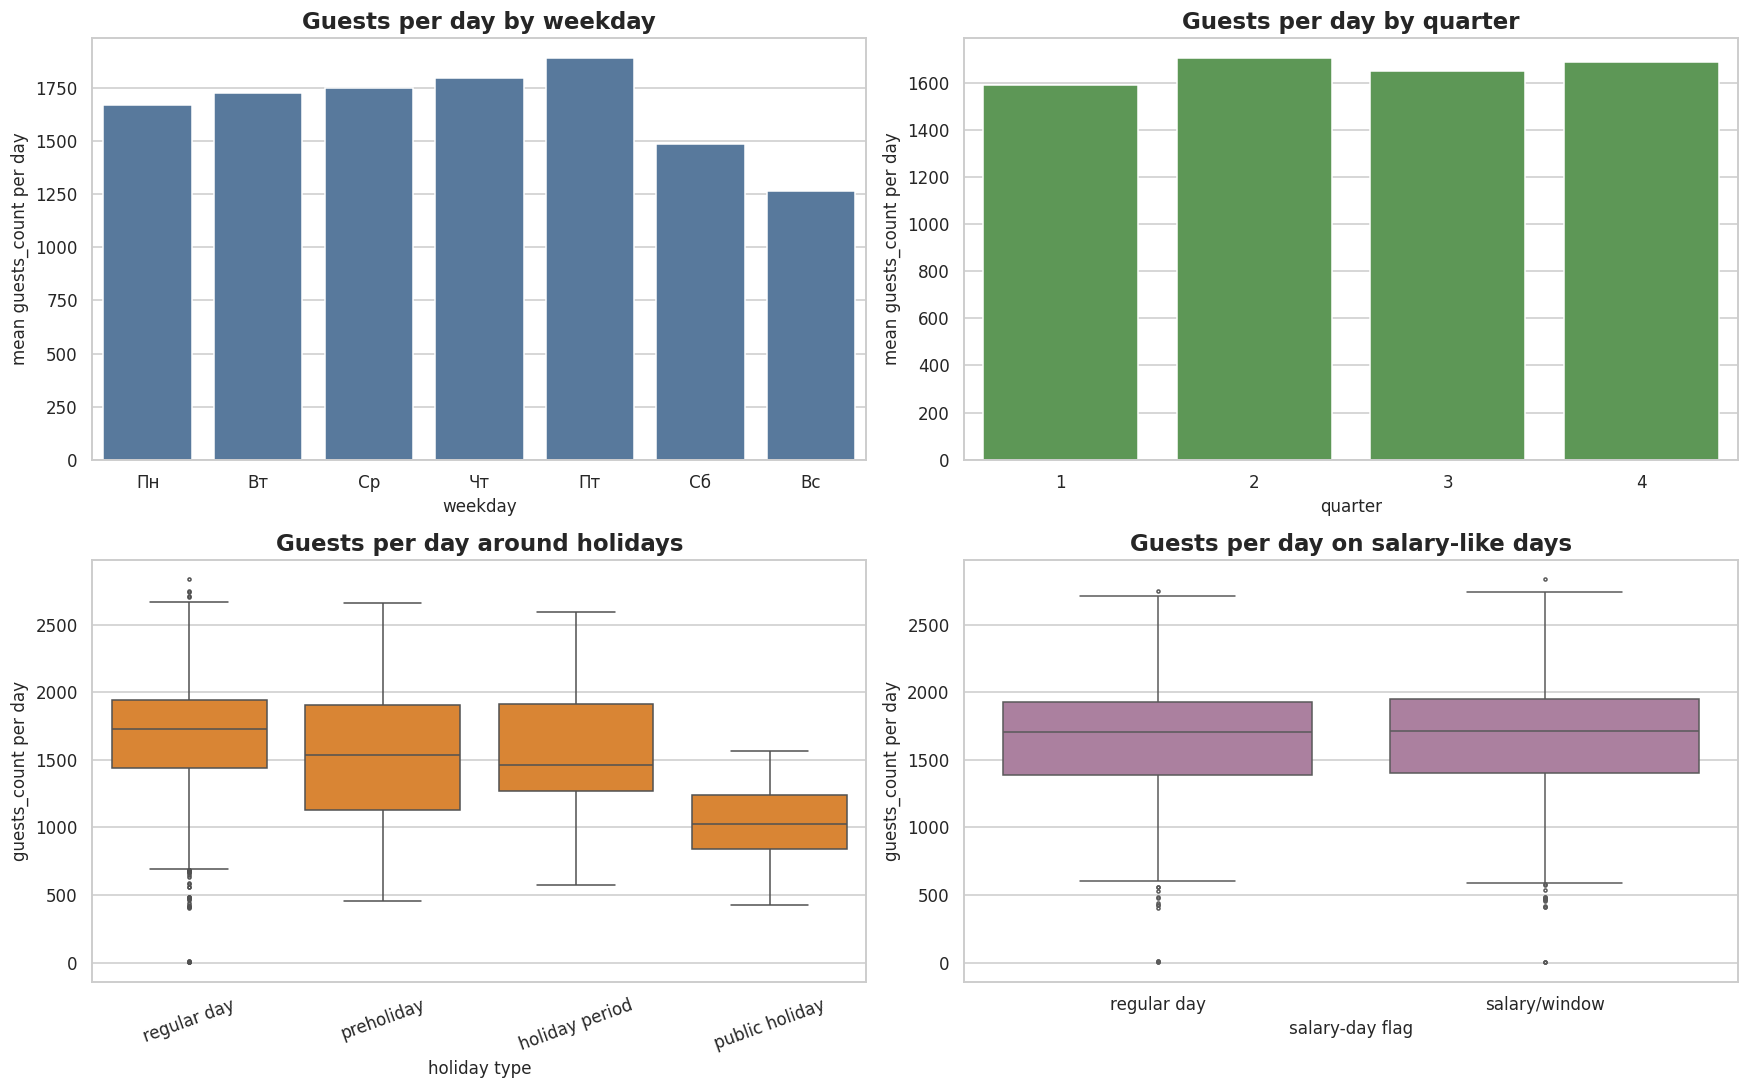

saved: artifacts\figures\12_eda_intraday_time.png


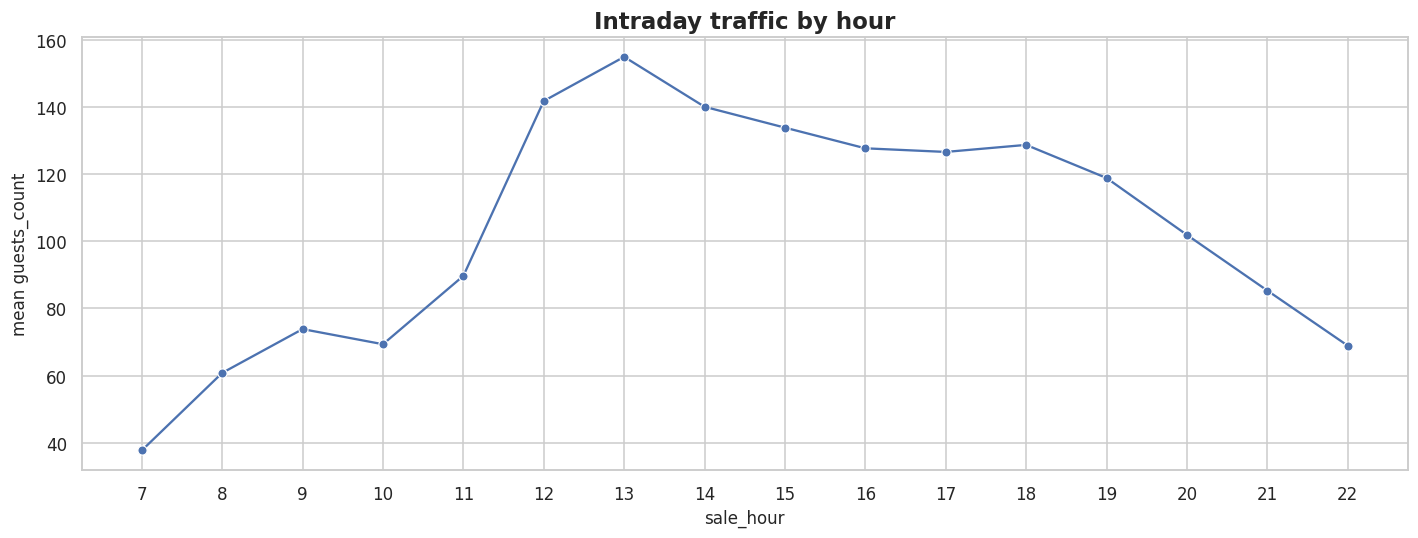

saved: artifacts\figures\13_eda_quarter_hour_heatmap.png


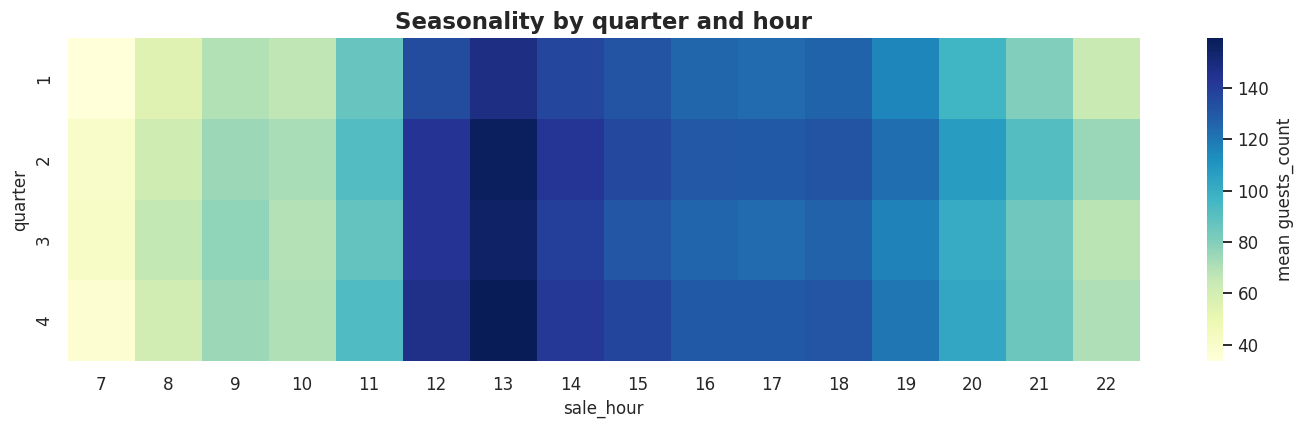

,slice,value
0,best_weekday,Friday
1,best_quarter,2
2,holiday_days,207
3,salary_window_days,669
4,peak_hour,13


**EDA conclusion.** The model should keep weekday/hour seasonality, quarter/month seasonality, Russian holiday features,
and salary-day proximity features. These slices also explain why validation must be time-based.

In [7]:

from crocs.ml.features import add_calendar_features

eda = df[["sale_date", "sale_hour", "guests_count"]].copy()
eda = add_calendar_features(eda)
eda["quarter"] = eda["sale_date"].dt.quarter
eda["salary_group"] = np.where(
    (eda["is_salary_day"] == 1) | (eda["is_month_end_salary_window"] == 1),
    "salary/window",
    "regular day",
)
eda["holiday_group"] = np.select(
    [
        eda["is_ru_public_holiday"].eq(1),
        eda["is_ru_preholiday"].eq(1),
        eda["is_ru_holiday_period"].eq(1),
    ],
    ["public holiday", "preholiday", "holiday period"],
    default="regular day",
)

daily_eda = eda.groupby("sale_date", as_index=False).agg(
    guests_count=("guests_count", "sum"),
    is_ru_public_holiday=("is_ru_public_holiday", "max"),
    is_ru_preholiday=("is_ru_preholiday", "max"),
    is_ru_holiday_period=("is_ru_holiday_period", "max"),
    is_salary_day=("is_salary_day", "max"),
    is_month_end_salary_window=("is_month_end_salary_window", "max"),
)
daily_eda["day_of_week"] = daily_eda["sale_date"].dt.dayofweek
daily_eda["weekday_name"] = daily_eda["sale_date"].dt.day_name()
daily_eda["month"] = daily_eda["sale_date"].dt.month
daily_eda["quarter"] = daily_eda["sale_date"].dt.quarter
daily_eda["year"] = daily_eda["sale_date"].dt.year
daily_eda["salary_group"] = np.where(
    daily_eda["is_salary_day"].eq(1) | daily_eda["is_month_end_salary_window"].eq(1),
    "salary/window",
    "regular day",
)
daily_eda["holiday_group"] = np.select(
    [
        daily_eda["is_ru_public_holiday"].eq(1),
        daily_eda["is_ru_preholiday"].eq(1),
        daily_eda["is_ru_holiday_period"].eq(1),
    ],
    ["public holiday", "preholiday", "holiday period"],
    default="regular day",
)

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
weekday_mean = daily_eda.groupby("weekday_name")["guests_count"].mean().reindex(DOW_ORDER)
sns.barplot(x=DOW_RU, y=weekday_mean.values, ax=axes[0, 0], color="#4C78A8")
axes[0, 0].set_title("Guests per day by weekday")
axes[0, 0].set_xlabel("weekday")
axes[0, 0].set_ylabel("mean guests_count per day")
quarter_mean = daily_eda.groupby("quarter")["guests_count"].mean()
sns.barplot(x=quarter_mean.index, y=quarter_mean.values, ax=axes[0, 1], color="#54A24B")
axes[0, 1].set_title("Guests per day by quarter")
axes[0, 1].set_xlabel("quarter")
axes[0, 1].set_ylabel("mean guests_count per day")
holiday_order = ["regular day", "preholiday", "holiday period", "public holiday"]
sns.boxplot(
    data=daily_eda,
    x="holiday_group",
    y="guests_count",
    order=[x for x in holiday_order if x in set(daily_eda["holiday_group"])],
    ax=axes[1, 0],
    color="#F58518",
    fliersize=2,
)
axes[1, 0].set_title("Guests per day around holidays")
axes[1, 0].set_xlabel("holiday type")
axes[1, 0].set_ylabel("guests_count per day")
axes[1, 0].tick_params(axis="x", rotation=20)
sns.boxplot(data=daily_eda, x="salary_group", y="guests_count", ax=axes[1, 1], color="#B279A2", fliersize=2)
axes[1, 1].set_title("Guests per day on salary-like days")
axes[1, 1].set_xlabel("salary-day flag")
axes[1, 1].set_ylabel("guests_count per day")
savefig("11_eda_weekday_quarter_holiday_salary.png")
plt.show()

fig, ax = plt.subplots(figsize=(13, 5))
sns.lineplot(data=eda, x="sale_hour", y="guests_count", estimator="mean", errorbar=None, marker="o", ax=ax)
ax.set_title("Intraday traffic by hour")
ax.set_xlabel("sale_hour")
ax.set_ylabel("mean guests_count")
ax.set_xticks(expected_hours)
savefig("12_eda_intraday_time.png")
plt.show()

pivot_quarter_hour = eda.pivot_table(index="quarter", columns="sale_hour", values="guests_count", aggfunc="mean")
fig, ax = plt.subplots(figsize=(13, 4))
sns.heatmap(pivot_quarter_hour, cmap="YlGnBu", ax=ax, cbar_kws={"label": "mean guests_count"})
ax.set_title("Seasonality by quarter and hour")
ax.set_xlabel("sale_hour")
ax.set_ylabel("quarter")
savefig("13_eda_quarter_hour_heatmap.png")
plt.show()

summary_slices = pd.DataFrame(
    {
        "slice": ["best_weekday", "best_quarter", "holiday_days", "salary_window_days", "peak_hour"],
        "value": [
            str(weekday_mean.idxmax()),
            str(quarter_mean.idxmax()),
            int(daily_eda["holiday_group"].ne("regular day").sum()),
            int(daily_eda["salary_group"].eq("salary/window").sum()),
            int(eda.groupby("sale_hour")["guests_count"].mean().idxmax()),
        ],
    }
)
display(summary_slices)

note("""
**EDA conclusion.** The model should keep weekday/hour seasonality, quarter/month seasonality, Russian holiday features,
and salary-day proximity features. These slices also explain why validation must be time-based.
""")


## 6. Анализ лагов и автокорреляции

Для почасового ресторанного ряда особенно важны лаги той же точки недели: вчера в тот же час,
неделя назад, две недели назад, четыре недели назад и год назад. Все лаги считаются только из прошлого.

,lag,corr,rows
0,lag_7d,0.881443,40431
1,lag_14d,0.844059,40319
2,lag_28d,0.808153,40095


saved: artifacts\figures\12_lag_correlations.png


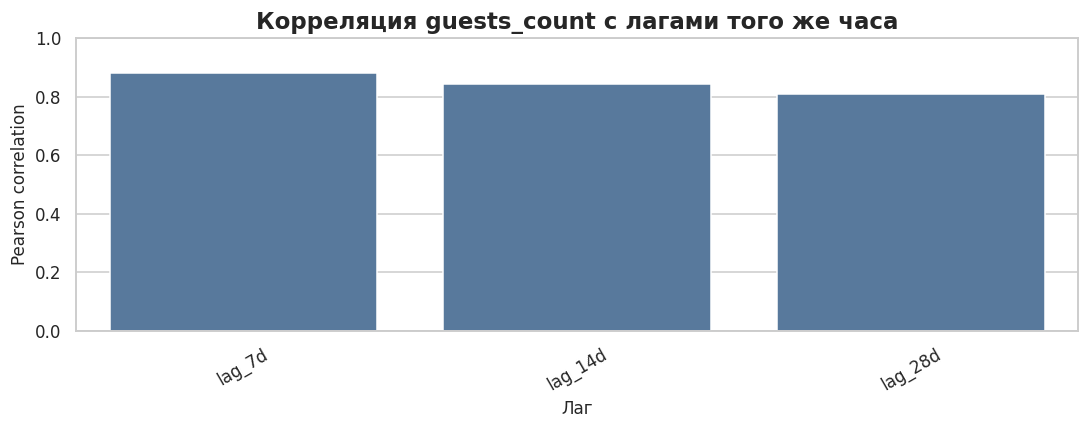

**Вывод.** Сильные недельные/многонедельные лаги означают, что модель должна помнить прошлые значения того же часа.
Если лаги слабые на отдельных периодах, это сигнал о смене режима или внешних факторах.

saved: artifacts\figures\13_daily_acf.png


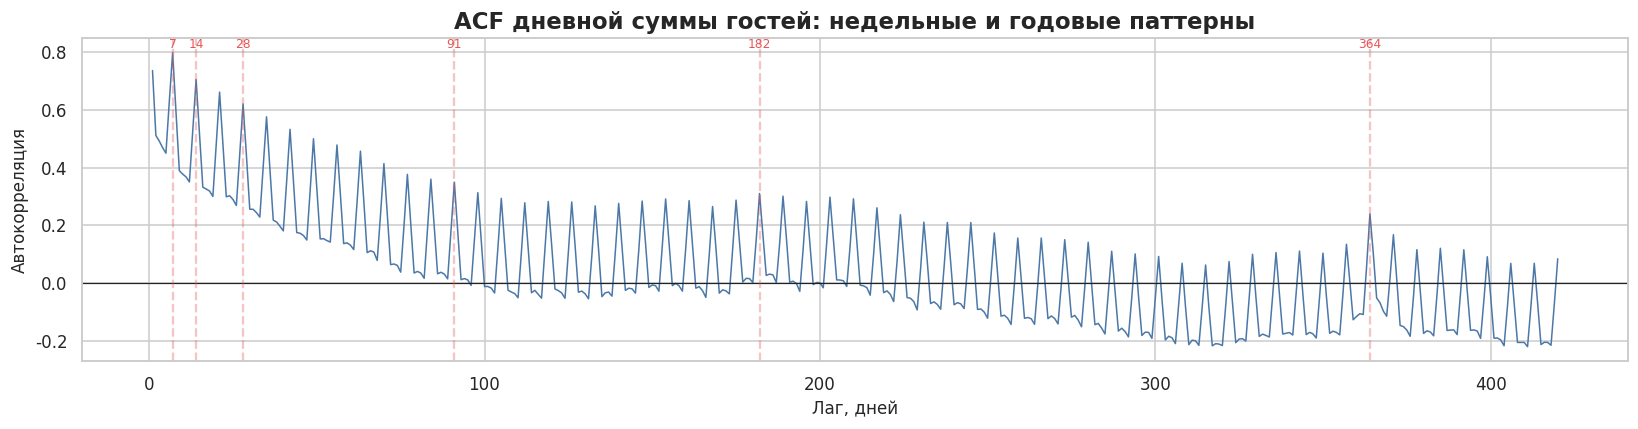

**Вывод.** ACF помогает выбрать лаги не вручную, а по структуре ряда.
Пики около кратных 7 дней подтверждают недельную сезонность, а длинные лаги полезны для годового контекста.

saved: artifacts\figures\14_actual_vs_lags_hexbin.png


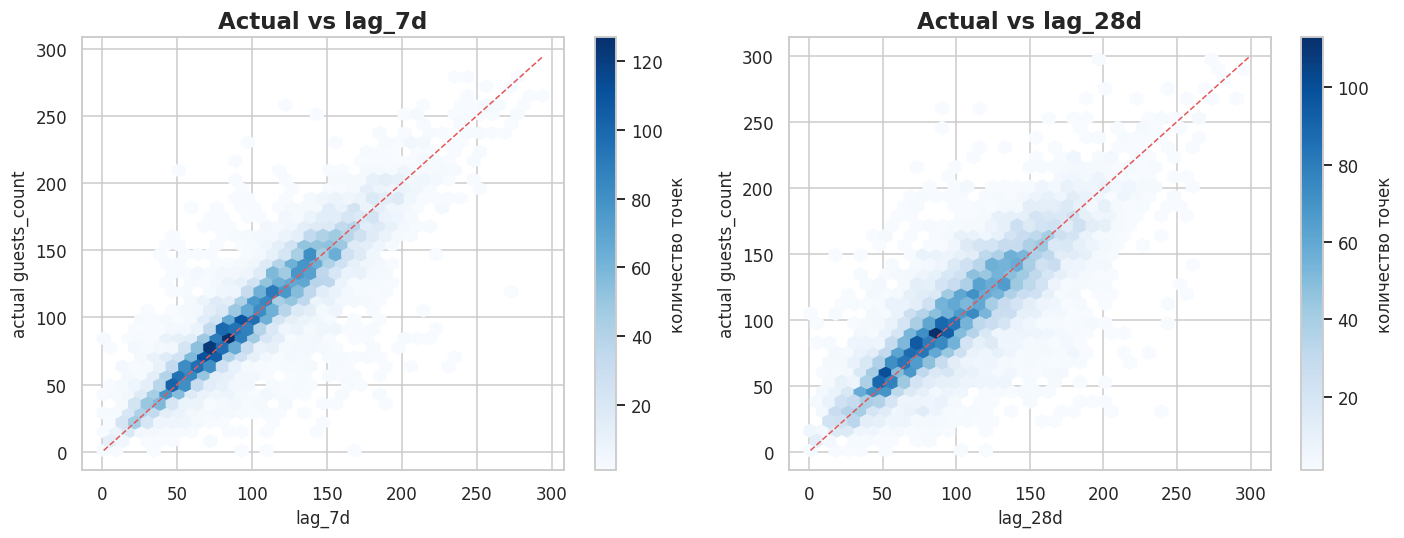

**Вывод.** Чем плотнее облако вдоль диагонали, тем сильнее лаг объясняет текущий спрос.
Отклонения от диагонали показывают часы/периоды, где одного сезонного лага недостаточно.

saved: artifacts\figures\15_recent_weeks_overlay.png


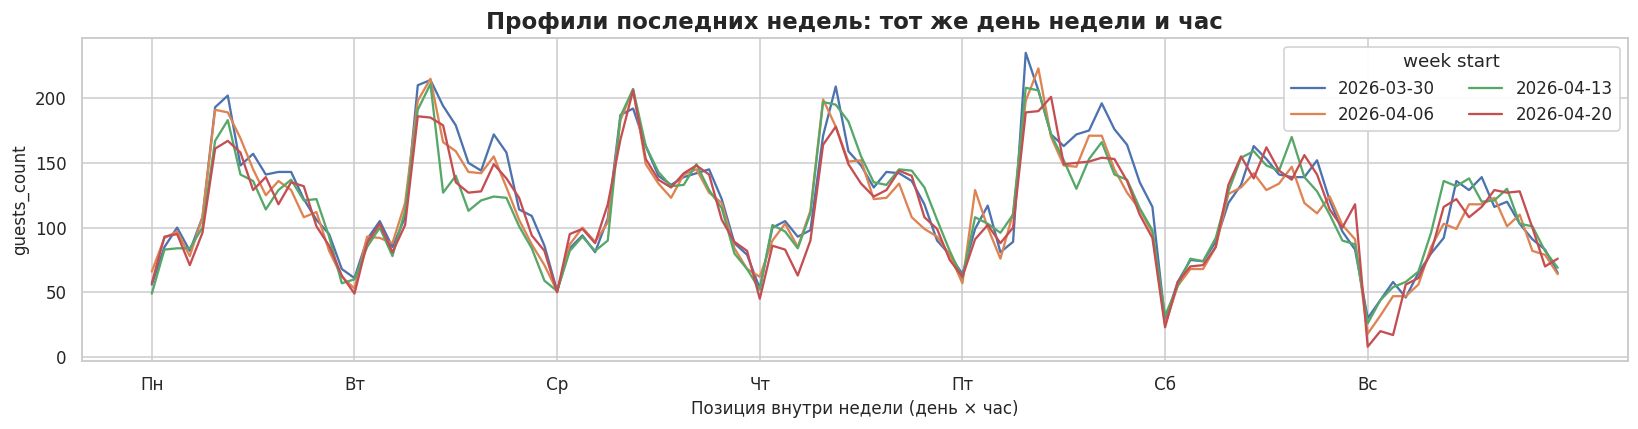

**Вывод.** Наложение последних недель показывает, насколько стабилен недельный профиль прямо перед validation.
Если линии близки, recent seasonal baseline будет трудно побить сложной моделью.

In [8]:
lag_days = [7, 14, 28]
lag_df = df.sort_values(["sale_hour", "sale_date"]).copy()
for lag in lag_days:
    lag_df[f"lag_{lag}d"] = lag_df.groupby("sale_hour")["guests_count"].shift(lag)

lag_corr = []
for lag in lag_days:
    col = f"lag_{lag}d"
    valid = lag_df[["guests_count", col]].dropna()
    corr = valid["guests_count"].corr(valid[col]) if len(valid) else np.nan
    lag_corr.append({"lag": col, "corr": corr, "rows": len(valid)})
lag_corr = pd.DataFrame(lag_corr)
display(lag_corr)

fig, ax = plt.subplots(figsize=(10, 4))
sns.barplot(data=lag_corr, x="lag", y="corr", ax=ax, color="#4C78A8")
ax.set_title("Корреляция guests_count с лагами того же часа")
ax.set_xlabel("Лаг")
ax.set_ylabel("Pearson correlation")
ax.tick_params(axis="x", rotation=30)
ax.set_ylim(0, max(1.0, np.nanmax(lag_corr["corr"]) + 0.05))
savefig("12_lag_correlations.png")
plt.show()
note("""
**Вывод.** Сильные недельные/многонедельные лаги означают, что модель должна помнить прошлые значения того же часа.
Если лаги слабые на отдельных периодах, это сигнал о смене режима или внешних факторах.
""")

daily_acf = daily.set_index("sale_date")["guests_sum"].asfreq("D")
acf_df = pd.DataFrame({"lag_days": range(1, 421)})
acf_df["acf"] = [daily_acf.autocorr(lag=int(lag)) for lag in acf_df["lag_days"]]
fig, ax = plt.subplots(figsize=(15, 4))
ax.plot(acf_df["lag_days"], acf_df["acf"], color="#4C78A8", linewidth=1.0)
ax.axhline(0, color="#222222", linewidth=0.8)
for x in [7, 14, 28, 91, 182, 364]:
    ax.axvline(x, color="#E45756", linestyle="--", alpha=0.35)
    ax.text(x, ax.get_ylim()[1], str(x), color="#E45756", ha="center", va="top", fontsize=8)
ax.set_title("ACF дневной суммы гостей: недельные и годовые паттерны")
ax.set_xlabel("Лаг, дней")
ax.set_ylabel("Автокорреляция")
savefig("13_daily_acf.png")
plt.show()
note("""
**Вывод.** ACF помогает выбрать лаги не вручную, а по структуре ряда.
Пики около кратных 7 дней подтверждают недельную сезонность, а длинные лаги полезны для годового контекста.
""")

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for ax, lag in zip(axes, [7, 28]):
    col = f"lag_{lag}d"
    sample = lag_df[["guests_count", col]].dropna().sample(min(8000, lag_df[col].notna().sum()), random_state=RANDOM_STATE)
    hb = ax.hexbin(sample[col], sample["guests_count"], gridsize=35, cmap="Blues", mincnt=1)
    lim_min = min(sample[col].min(), sample["guests_count"].min())
    lim_max = max(sample[col].max(), sample["guests_count"].max())
    ax.plot([lim_min, lim_max], [lim_min, lim_max], color="#E45756", linestyle="--", linewidth=1)
    ax.set_title(f"Actual vs lag_{lag}d")
    ax.set_xlabel(col)
    ax.set_ylabel("actual guests_count")
    fig.colorbar(hb, ax=ax, label="количество точек")
savefig("14_actual_vs_lags_hexbin.png")
plt.show()
note("""
**Вывод.** Чем плотнее облако вдоль диагонали, тем сильнее лаг объясняет текущий спрос.
Отклонения от диагонали показывают часы/периоды, где одного сезонного лага недостаточно.
""")

last_monday = df["sale_date"].max() - pd.Timedelta(days=int(df["sale_date"].max().dayofweek))
week_starts = [last_monday - pd.Timedelta(days=7 * i) for i in range(3, -1, -1)]
week_lines = []
for start in week_starts:
    end = start + pd.Timedelta(days=6)
    part = df[df["sale_date"].between(start, end)].copy()
    if part.empty:
        continue
    part["week_start"] = start.strftime("%Y-%m-%d")
    part["position"] = part["sale_date"].dt.dayofweek * len(expected_hours) + (part["sale_hour"] - min_hour)
    week_lines.append(part)
week_cmp = pd.concat(week_lines, ignore_index=True)
fig, ax = plt.subplots(figsize=(15, 4))
sns.lineplot(data=week_cmp, x="position", y="guests_count", hue="week_start", estimator=None, units="week_start", lw=1.5, ax=ax)
ax.set_title("Профили последних недель: тот же день недели и час")
ax.set_xlabel("Позиция внутри недели (день × час)")
ax.set_ylabel("guests_count")
ax.set_xticks([i * len(expected_hours) for i in range(7)])
ax.set_xticklabels(DOW_RU)
ax.legend(title="week start", ncol=2)
savefig("15_recent_weeks_overlay.png")
plt.show()
note("""
**Вывод.** Наложение последних недель показывает, насколько стабилен недельный профиль прямо перед validation.
Если линии близки, recent seasonal baseline будет трудно побить сложной моделью.
""")

## 7. Выбросы и нестабильные периоды

Смотрим максимальные и минимальные дни, почасовые пики и периоды с резкой сменой распределения.

**Топ дней по суммарному спросу**

,sale_date,guests_sum,guests_mean,hours,rolling_7d_mean,rolling_28d_median,rolling_90d_mean
296,2019-10-25,2835,177.1875,16,2264.285714,2268.0,2037.800000
289,2019-10-18,2751,171.9375,16,2258.285714,2268.0,2001.077778
149,2019-05-31,2739,171.1875,16,2249.142857,2219.0,1976.700000
345,2019-12-13,2712,169.5000,16,2252.285714,2158.0,2155.833333
247,2019-09-06,2706,169.1250,16,2196.428571,1909.0,1909.677778
113,2019-04-25,2668,166.7500,16,2224.285714,2160.5,1842.566667
160,2019-06-11,2661,166.3125,16,2268.285714,2394.0,2035.633333
324,2019-11-22,2640,165.0000,16,2189.857143,2168.0,2158.277778
282,2019-10-11,2634,164.6250,16,2175.285714,2248.0,1965.588889
156,2019-06-07,2606,162.8750,16,2268.000000,2350.5,2022.133333


**Минимальные дни по суммарному спросу**

,sale_date,guests_sum,guests_mean,hours,rolling_7d_mean,rolling_28d_median,rolling_90d_mean
1170,2022-05-24,2,1.000000,2,1117.428571,1829.5,1488.688889
1168,2022-03-15,2,1.000000,2,1730.142857,1829.5,1529.555556
1171,2022-06-30,3,1.500000,2,795.285714,1793.5,1471.155556
1169,2022-03-31,3,1.000000,3,1440.428571,1829.5,1510.200000
1172,2022-07-06,8,2.666667,3,518.285714,1793.5,1457.633333
1173,2022-07-24,11,2.750000,4,252.857143,1793.5,1439.600000
1174,2022-07-27,11,5.500000,2,5.714286,1780.5,1420.977778
1184,2022-08-07,406,25.375000,16,710.428571,780.0,1325.555556
454,2020-03-31,410,27.333333,15,851.285714,1375.5,1701.988889
453,2020-03-30,414,27.600000,15,972.142857,1417.0,1705.922222


**Почасовые пики**

,sale_date,sale_hour,guests_count,timestamp,date,day_of_week,weekday_name,month,year,is_weekend,menu_period
3958,2019-09-06,13,299,2019-09-06 13:00:00,2019-09-06,4,Friday,9,2019,False,main_menu
4742,2019-10-25,13,297,2019-10-25 13:00:00,2019-10-25,4,Friday,10,2019,False,main_menu
4630,2019-10-18,13,295,2019-10-18 13:00:00,2019-10-18,4,Friday,10,2019,False,main_menu
4022,2019-09-10,13,294,2019-09-10 13:00:00,2019-09-10,1,Tuesday,9,2019,False,main_menu
4614,2019-10-17,13,291,2019-10-17 13:00:00,2019-10-17,3,Thursday,10,2019,False,main_menu
2486,2019-06-06,13,290,2019-06-06 13:00:00,2019-06-06,3,Thursday,6,2019,False,main_menu
4406,2019-10-04,13,288,2019-10-04 13:00:00,2019-10-04,4,Friday,10,2019,False,main_menu
2502,2019-06-07,13,285,2019-06-07 13:00:00,2019-06-07,4,Friday,6,2019,False,main_menu
3926,2019-09-04,13,284,2019-09-04 13:00:00,2019-09-04,2,Wednesday,9,2019,False,main_menu
4150,2019-09-18,13,284,2019-09-18 13:00:00,2019-09-18,2,Wednesday,9,2019,False,main_menu


saved: artifacts\figures\16_daily_outliers.png


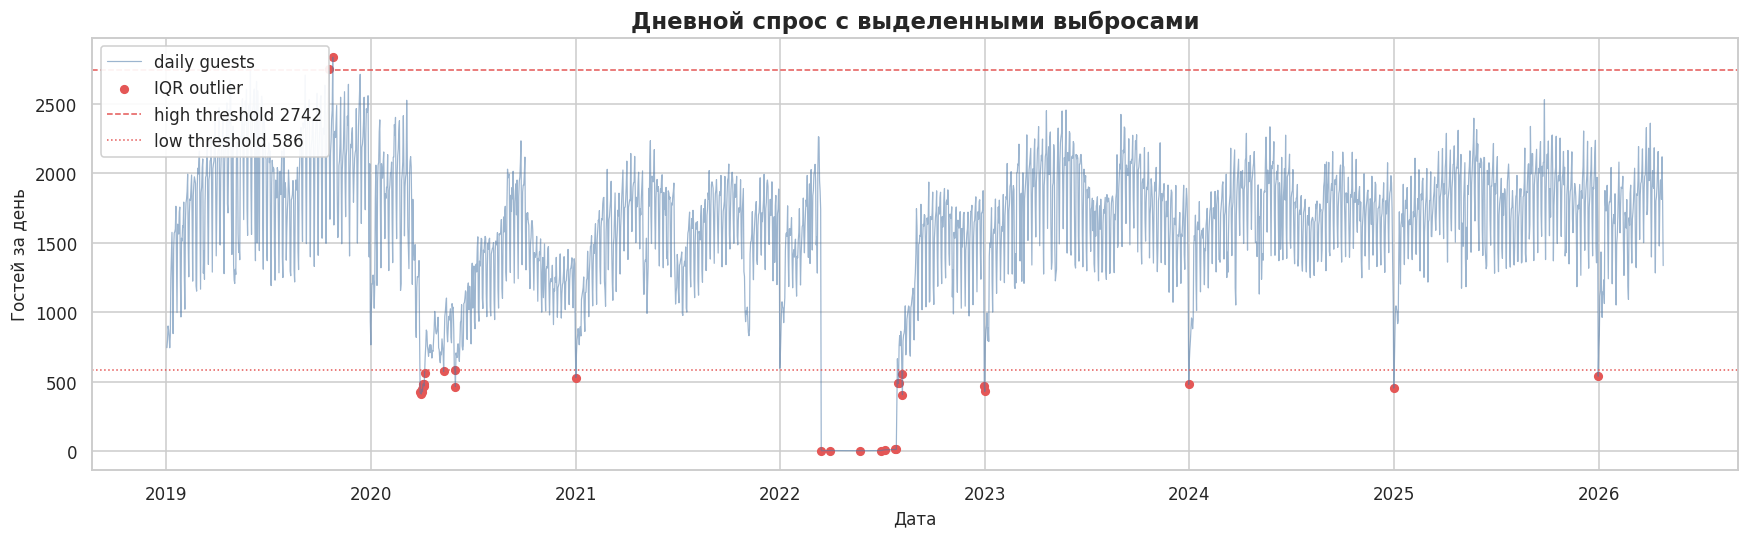

**Вывод.** Дневных IQR-выбросов: `31`.
Их лучше анализировать как события/смены режима, а не просто удалять: для прогноза важно не потерять реальные пики.

saved: artifacts\figures\17_year_distribution_and_hourly_peaks.png


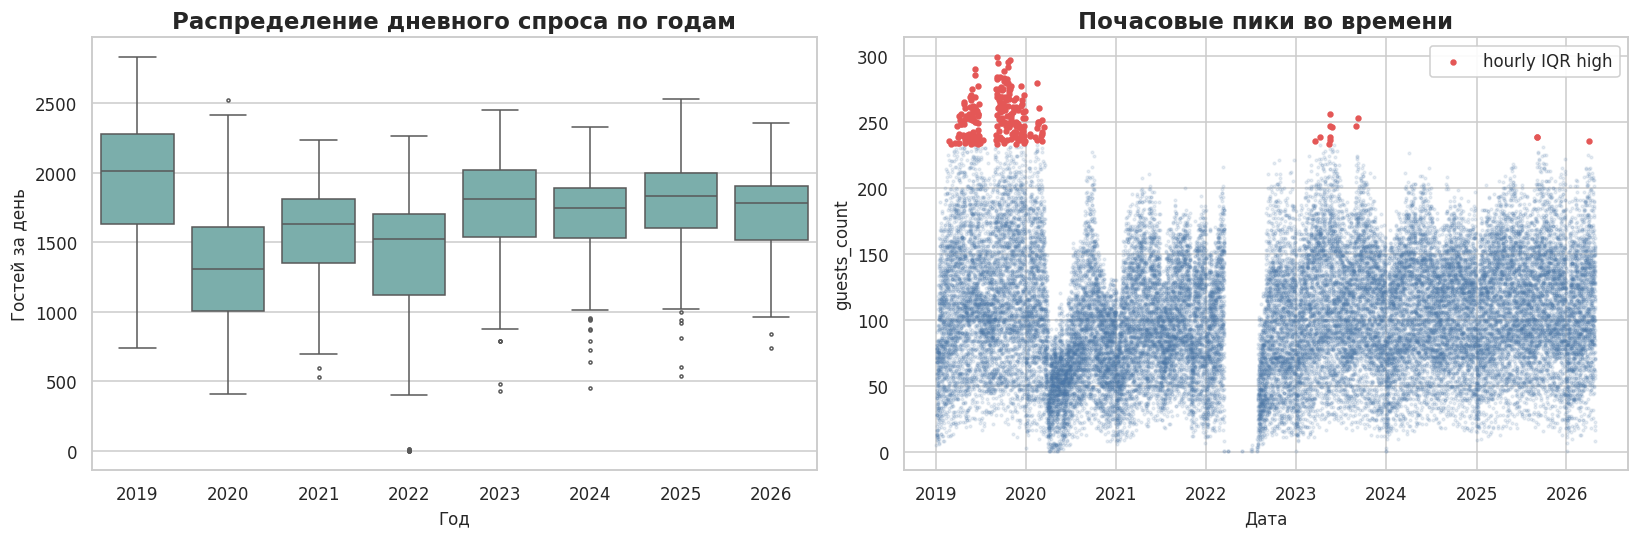

**Вывод.** Сравнение по годам показывает нестабильность распределения, а почасовые пики помогают понять,
где модель будет ошибаться сильнее всего. Для следующих итераций нужны флаги праздников, промо и особых периодов.

In [9]:
top_days = daily.sort_values("guests_sum", ascending=False).head(12)
low_days = daily.sort_values("guests_sum", ascending=True).head(12)
top_hours = df.sort_values("guests_count", ascending=False).head(15)

display(Markdown("**Топ дней по суммарному спросу**"))
display(top_days)
display(Markdown("**Минимальные дни по суммарному спросу**"))
display(low_days)
display(Markdown("**Почасовые пики**"))
display(top_hours)

daily_q1, daily_q3 = daily["guests_sum"].quantile([0.25, 0.75])
daily_iqr = daily_q3 - daily_q1
daily_high = daily_q3 + 1.5 * daily_iqr
daily_low = max(0, daily_q1 - 1.5 * daily_iqr)
daily["is_outlier_iqr"] = (daily["guests_sum"] > daily_high) | (daily["guests_sum"] < daily_low)

fig, ax = plt.subplots(figsize=(16, 5))
ax.plot(daily["sale_date"], daily["guests_sum"], linewidth=0.8, color="#4C78A8", alpha=0.55, label="daily guests")
out = daily[daily["is_outlier_iqr"]]
ax.scatter(out["sale_date"], out["guests_sum"], color="#E45756", s=25, label="IQR outlier")
ax.axhline(daily_high, color="#E45756", linestyle="--", linewidth=1, label=f"high threshold {daily_high:.0f}")
ax.axhline(daily_low, color="#E45756", linestyle=":", linewidth=1, label=f"low threshold {daily_low:.0f}")
ax.set_title("Дневной спрос с выделенными выбросами")
ax.set_xlabel("Дата")
ax.set_ylabel("Гостей за день")
format_date_axis(ax)
ax.legend(loc="upper left")
savefig("16_daily_outliers.png")
plt.show()
note(f"""
**Вывод.** Дневных IQR-выбросов: `{int(daily['is_outlier_iqr'].sum())}`.
Их лучше анализировать как события/смены режима, а не просто удалять: для прогноза важно не потерять реальные пики.
""")

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
sns.boxplot(data=daily.assign(year=daily["sale_date"].dt.year), x="year", y="guests_sum", ax=axes[0], color="#72B7B2", fliersize=2)
axes[0].set_title("Распределение дневного спроса по годам")
axes[0].set_xlabel("Год")
axes[0].set_ylabel("Гостей за день")
hour_outliers = df[df["guests_count"] > high_threshold]
axes[1].scatter(df["timestamp"], df["guests_count"], s=3, alpha=0.12, color="#4C78A8")
axes[1].scatter(hour_outliers["timestamp"], hour_outliers["guests_count"], s=10, color="#E45756", label="hourly IQR high")
axes[1].set_title("Почасовые пики во времени")
axes[1].set_xlabel("Дата")
axes[1].set_ylabel("guests_count")
format_date_axis(axes[1])
axes[1].legend()
savefig("17_year_distribution_and_hourly_peaks.png")
plt.show()
note("""
**Вывод.** Сравнение по годам показывает нестабильность распределения, а почасовые пики помогают понять,
где модель будет ошибаться сильнее всего. Для следующих итераций нужны флаги праздников, промо и особых периодов.
""")

## 8. Дополнительные данные для следующих итераций

Основной фокус этого ноутбука - `train.csv`. В следующих итерациях к ML-модели стоит добавить внешние признаки:

- праздники и переносы выходных: ресторанный трафик часто меняется в длинные выходные;
- предпраздничные дни: спрос может отличаться от обычного дня недели;
- погода: температура, осадки и экстремальные условия могут менять поток гостей, но это не главный фокус первой версии;
- школьные каникулы: меняют дневной спрос семейной аудитории;
- локальные события рядом с метро Аэропорт: матчи, концерты, городские мероприятия;
- промо и изменения меню: могут давать пики, которые не объясняются календарем;
- флаги нестабильных периодов: covid, rebrand, изменения режима работы.

Эти данные нужны уже для следующего слоя моделирования. В этом ноутбуке они только перечислены как план, без обучения модели.


## 9. Итоги EDA

Что видно по `train.csv`:

- данные имеют выраженную сезонность по часам, поэтому `sale_hour` обязательно нужен как признак;
- дни недели отличаются между собой, значит нужны `day_of_week` и `is_weekend`;
- месяцы, кварталы и общая сезонность заметны на агрегатах, поэтому стоит учитывать `month`, `quarter`, `day_of_year`, `week_of_year`;
- праздники, предпраздничные дни и длинные выходные могут менять посещаемость относительно обычного календарного паттерна;
- зарплатные дни и дни рядом с ними стоит проверить как отдельный фактор спроса;
- дата `2022-09-22` отмечена как начало более стабильного периода после резкого провала и восстановления;
- лаги нужны, но их стоит держать умеренными: в EDA достаточно смотреть недельные сдвиги `7`, `14`, `28` дней;
- выбросы и нестабильные периоды нужно учитывать отдельно перед обучением модели.

Следующий этап: дорабатывать feature engineering и обучение в существующем коде проекта, а не внутри этого notebook. Этот файл остается EDA-отчетом и не считает модельные метрики.
